In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('messy_cutomer_sales_data.csv')

In [72]:
df

,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country
0,1,Ankit,F,36.0,Mumbai,31/12/2024,01/01/1970,2460.355,2.0,Unknown,Not Provided,Canada
1,2,Ravi,F,70.0,Kolkata,07/12/2022,01/01/1970,2460.355,10.0,user1mail.com,Not Provided,Canada
2,3,Ravi,F,66.0,Ahmedabad,07/12/2022,01/01/1970,2460.355,10.0,user2@mail.com,Not Provided,India
3,4,Ankit,M,44.0,Kolkata,07/12/2022,01/01/1970,2460.355,10.0,Unknown,9316267914,USA
4,5,Rahul,M,70.0,Ahmedabad,09/07/2025,01/01/1970,2460.355,10.0,user4mail.com,9234603292,USA
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,NaN,M,70.0,Delhi,07/12/2022,01/01/1970,2460.355,10.0,Unknown,9669860802,UK
9996,9997,Ankit,F,70.0,Chennai,07/12/2022,01/01/1970,2460.355,5.0,Unknown,Not Provided,USA
9997,9998,NaN,F,35.0,Kolkata,24/05/2022,01/01/1970,2460.355,10.0,Unknown,Not Provided,USA
9998,9999,Pooja,F,24.0,Chennai,07/12/2022,01/01/1970,2460.355,10.0,user9998mail.com,9716472962,UK


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          7621 non-null   object 
 1   Name                8342 non-null   object 
 2   Gender              7545 non-null   object 
 3   Age                 7424 non-null   float64
 4   City                8870 non-null   object 
 5   Signup_Date         7471 non-null   object 
 6   Last_purchase_date  6714 non-null   object 
 7   purchase_amount     4967 non-null   float64
 8   feedback_score      7538 non-null   float64
 9   email               4934 non-null   object 
 10  Phone_number        7556 non-null   object 
 11  Country             8296 non-null   object 
dtypes: float64(3), object(9)
memory usage: 937.6+ KB


In [9]:
 df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,7424.0,78.904364,87.817619,-5.0,-5.0,43.0,200.0,200.00
purchase_amount,4967.0,713.654008,2002.187228,-999.0,-999.0,-999.0,2437.6,4998.67
feedback_score,7538.0,4.008092,4.619336,-1.0,-1.0,3.0,10.0,10.00


In [10]:
df.shape

(10000, 12)

In [11]:
df.isnull().sum()

CustomerID            2379
Name                  1658
Gender                2455
Age                   2576
City                  1130
Signup_Date           2529
Last_purchase_date    3286
purchase_amount       5033
feedback_score        2462
email                 5066
Phone_number          2444
Country               1704
dtype: int64

In [14]:
df.isnull().sum()/len(df)*100

CustomerID            23.79
Name                  16.58
Gender                24.55
Age                   25.76
City                  11.30
Signup_Date           25.29
Last_purchase_date    32.86
purchase_amount       50.33
feedback_score        24.62
email                 50.66
Phone_number          24.44
Country               17.04
dtype: float64

In [15]:
df.dropna().shape

(180, 12)

In [16]:
df[df.duplicated()].shape

(0, 12)

In [21]:
df[df.duplicated()]

,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country


In [22]:
df['CustomerID'].value_counts()

CustomerID
10000    1
C2       1
3        1
C4       1
5        1
        ..
C12      1
10       1
C9       1
8        1
7        1
Name: count, Length: 7621, dtype: int64

In [27]:
df['CustomerID'].value_counts()

CustomerID
10000    1
C2       1
3        1
C4       1
5        1
        ..
C12      1
10       1
C9       1
8        1
7        1
Name: count, Length: 7621, dtype: int64

In [25]:
df['CustomerID'].value_counts().head(10)

CustomerID
10000    1
C2       1
3        1
C4       1
5        1
9979     1
9978     1
9976     1
9975     1
9974     1
Name: count, dtype: int64

In [26]:
df[df['CustomerID'] == '10000']

,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country
9999,10000,Kiran,F,-5.0,Hyderabad,03/07/2022,21/03/2025,2254.23,NaN,user9999mail.com,0,USA


In [29]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print('-'*50)

Name
Rahul     876
Sneha     870
Kiran     868
Ankit     845
Priya     831
Ravi      828
Neha      813
Amit      809
Simran    801
Pooja     801
Name: count, dtype: int64
--------------------------------------------------
Gender
Male      1325
female    1270
F         1262
M         1249
male      1226
Female    1213
Name: count, dtype: int64
--------------------------------------------------
City
Hyderabad    1144
Mumbai       1133
Pune         1130
Bangalore    1120
Chennai      1109
Delhi        1091
Ahmedabad    1087
Kolkata      1056
Name: count, dtype: int64
--------------------------------------------------
feedback_score
 10.0    2521
-1.0     2489
 3.0      556
 1.0      532
 5.0      522
 2.0      495
 4.0      423
Name: count, dtype: int64
--------------------------------------------------
Country
USA          1679
Australia    1660
Canada       1658
UK           1658
India        1641
Name: count, dtype: int64
--------------------------------------------------


# Handling Missing Data

In [30]:
df.isnull().sum()

CustomerID            2379
Name                  1658
Gender                2455
Age                   2576
City                  1130
Signup_Date           2529
Last_purchase_date    3286
purchase_amount       5033
feedback_score        2462
email                 5066
Phone_number          2444
Country               1704
dtype: int64

In [32]:
df.dropna(subset = ['CustomerID'], inplace = True)

In [49]:
df.shape

(7621, 12)

In [36]:
df.isnull().sum()

CustomerID               0
Name                  1240
Gender                1853
Age                   1931
City                   892
Signup_Date           1948
Last_purchase_date    2525
purchase_amount       3797
feedback_score        1874
email                 3826
Phone_number          1847
Country               1326
dtype: int64

In [37]:
df['Age'].unique()

array([ nan,  66.,  44., 200.,  64.,  -5.,  62.,  38.,  26.,  47.,  21.,
        42.,  22.,  52.,  24.,  59.,  23.,  68.,  51.,  43.,  57.,  70.,
        33.,  46.,  39.,  29.,  67.,  35.,  37.,  18.,  58.,  28.,  30.,
        65.,  45.,  50.,  31.,  20.,  61.,  41.,  36.,  54.,  53.,  48.,
        69.,  19.,  49.,  56.,  40.,  60.,  25.,  55.,  63.,  32.,  27.,
        34.])

In [38]:
import re
def extract_age(age):
    age_num = re.findall('[0-9]+', str(age))
    if len(age_num) >0:
        return age_num[0]
    else:
        return age
df['Age'] = df['Age'].apply(lambda x: extract_age(x))

In [39]:
df_age = df[df['Age'] != 'nan']['Age']

In [40]:
age_median = int(df_age.dropna().astype('int64').median())

In [41]:
age_median

43

In [42]:
df.replace('nan', age_median, inplace = True)

In [43]:
df['Age'].fillna(age_median, inplace = True)

C:\Users\vishw\AppData\Local\Temp\ipykernel_17612\490034067.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(age_median, inplace = True)


In [44]:
df['Age'].unique()

array([43, '66', '44', '200', '64', '5', '62', '38', '26', '47', '21',
       '42', '22', '52', '24', '59', '23', '68', '51', '43', '57', '70',
       '33', '46', '39', '29', '67', '35', '37', '18', '58', '28', '30',
       '65', '45', '50', '31', '20', '61', '41', '36', '54', '53', '48',
       '69', '19', '49', '56', '40', '60', '25', '55', '63', '32', '27',
       '34'], dtype=object)

In [47]:
df.isnull().sum()

CustomerID               0
Name                  1240
Gender                1853
Age                      0
City                   892
Signup_Date           1948
Last_purchase_date    2525
purchase_amount          0
feedback_score        1874
email                 3826
Phone_number          1847
Country               1326
dtype: int64

In [46]:
df['purchase_amount'].fillna(df['purchase_amount'].median(), inplace = True)

C:\Users\vishw\AppData\Local\Temp\ipykernel_17612\2032295570.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['purchase_amount'].fillna(df['purchase_amount'].median(), inplace = True)


In [48]:
df['purchase_amount'].unique()

array([-999.  ,  887.49, 2712.5 , ..., 2829.14, 3796.11, 2254.23],
      shape=(1888,))

In [54]:
df.isnull().sum()

CustomerID              0
Name                    0
Gender                636
Age                     0
City                  264
Signup_Date           586
Last_purchase_date    821
purchase_amount         0
feedback_score        591
email                   0
Phone_number            0
Country               429
dtype: int64

In [53]:
df.dropna(subset = ['Phone_number'], inplace = True)

In [55]:
df.shape

(2396, 12)

In [59]:
df['feedback_score'].fillna(df['feedback_score'].mode()[0], inplace = True)

C:\Users\vishw\AppData\Local\Temp\ipykernel_17612\2991758622.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['feedback_score'].fillna(df['feedback_score'].mode()[0], inplace = True)


In [60]:
df['feedback_score'].unique()

array([-1., 10.,  3.,  2.,  5.,  1.,  4.])

In [70]:
df.isnull().sum()

CustomerID            0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           2
Last_purchase_date    1
purchase_amount       0
feedback_score        0
email                 0
Phone_number          0
Country               0
dtype: int64

In [74]:
for col in ['Gender', 'City', 'Country']:
    df[col].fillna(df[col].mode()[0], inplace =True)

C:\Users\vishw\AppData\Local\Temp\ipykernel_3848\161572788.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace =True)


In [67]:
for i in ['Signup_Date', 'Last_purchase_date']:
    df[i].ffill(inplace = True)

In [73]:
df['Last_purchase_date'].unique()

array([nan, '20/06/2023', '15/11/2021', 'missing', '30/05/2022',
       '18/05/2025', '14/06/2024', '05/10/2024', '05/06/2024',
       '16/10/2020', '01/12/2020', '20/01/2026', '08/03/2025',
       '13/04/2023', '04/05/2022', '26/12/2023', '05/03/2022',
       '27/07/2025', '26/12/2022', '18/11/2023', '25/12/2020',
       '06/03/2025', '03/05/2025', '08/06/2021', '01/01/2026',
       '21/06/2025', '20/03/2021', '08/11/2021', '25/10/2021',
       '21/10/2023', '22/06/2021', '18/06/2021', '07/03/2023',
       '08/04/2025', '04/11/2025', '19/12/2025', '12/03/2024',
       '24/09/2025', '11/08/2024', '22/01/2026', '25/01/2023',
       '01/08/2021', '20/05/2021', '18/02/2023', '11/02/2024',
       '25/05/2025', '05/06/2022', '27/09/2023', '25/03/2023',
       '09/07/2024', '28/07/2025', '31/05/2024', '05/10/2023',
       '03/01/2021', '05/12/2022', '09/09/2024', '21/09/2021',
       '16/09/2023', '11/11/2024', '11/07/2021', '05/09/2020',
       '21/08/2021', '11/09/2020', '06/12/2022', '18/

In [69]:
df['Last_purchase_date'].ffill(inplace = True)

In [71]:
df_l = df[df['Last_purchase_date'] != 'nan']['Last_purchase_date']

In [72]:
df_l.dropna()

2       20/06/2023
4       20/06/2023
7       15/11/2021
9          missing
12         missing
           ...    
9984    23/10/2021
9989    14/03/2023
9992    08/08/2025
9993    08/08/2025
9999    21/03/2025
Name: Last_purchase_date, Length: 2395, dtype: object

In [21]:
df['Last_purchase_date'].unique()

array(['01/01/1970'], dtype=object)

In [20]:
df['Last_purchase_date'] = df['Last_purchase_date'].dt.strftime('%d/%m/%Y')

In [23]:
df['Last_purchase_date'].shape

(10000,)

In [30]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], errors='coerce').fillna(pd.to_datetime(df['Signup_Date'], errors='coerce').mode()[0]).dt.strftime('%d/%m/%Y')

C:\Users\vishw\AppData\Local\Temp\ipykernel_3848\1549585130.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], errors='coerce').fillna(pd.to_datetime(df['Signup_Date'], errors='coerce').mode()[0]).dt.strftime('%d/%m/%Y')
C:\Users\vishw\AppData\Local\Temp\ipykernel_3848\1549585130.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], errors='coerce').fillna(pd.to_datetime(df['Signup_Date'], errors='coerce').mode()[0]).dt.strftime('%d/%m/%Y')


In [31]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], errors='coerce').fillna(pd.to_datetime(df['Signup_Date'], errors='coerce').median()).dt.strftime('%d/%m/%Y')

C:\Users\vishw\AppData\Local\Temp\ipykernel_3848\1073025981.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], errors='coerce').fillna(pd.to_datetime(df['Signup_Date'], errors='coerce').median()).dt.strftime('%d/%m/%Y')
C:\Users\vishw\AppData\Local\Temp\ipykernel_3848\1073025981.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Signup_Date'] = pd.to_datetime(df['Signup_Date'], errors='coerce').fillna(pd.to_datetime(df['Signup_Date'], errors='coerce').median()).dt.strftime('%d/%m/%Y')


In [32]:
df['Signup_Date'].unique()

array(['31/12/2024', '07/12/2022', '09/07/2025', ..., '20/02/2022',
       '09/02/2024', '24/05/2022'], shape=(1841,), dtype=object)

In [34]:
df['purchase_amount'] = df['purchase_amount'].fillna(df['purchase_amount'].median())

In [36]:
df['purchase_amount'] = pd.to_numeric(df['purchase_amount'], errors='coerce').fillna(df['purchase_amount'].median())

In [38]:
df['purchase_amount'] = df['purchase_amount'].mask(df['purchase_amount'] <= 0).fillna(df['purchase_amount'][df['purchase_amount'] > 0].median())

In [40]:
df['feedback_score'] = df['feedback_score'].mask(df['feedback_score'] < 0).fillna(df['feedback_score'][df['feedback_score'] >= 0].mode()[0])

In [42]:
df['Age'] = df['Age'].mask(df['Age'] <= 0).fillna(df['Age'][df['Age'] > 0].median())

In [45]:
df['Age']

0       36.0
1       70.0
2       66.0
3       44.0
4       70.0
        ... 
9995    70.0
9996    70.0
9997    35.0
9998    24.0
9999    70.0
Name: Age, Length: 10000, dtype: float64

In [44]:
df['Age'] = df['Age'].mask((df['Age'] <= 0) | (df['Age'] > 100)).fillna(df['Age'][(df['Age'] > 0) & (df['Age'] <= 100)].median())

In [50]:
df['Gender'] = df['Gender'].replace({'Male': 'M','male':'M','Female':'F', 'female': 'F', 'm': 'M', 'f': 'F', 'Man': 'M', 'Woman': 'F'})

In [51]:
df['Gender']

0       F
1       F
2       F
3       M
4       M
       ..
9995    M
9996    F
9997    F
9998    F
9999    F
Name: Gender, Length: 10000, dtype: object

In [56]:
df['Phone_number'] = df['Phone_number'].fillna('Unknown')

In [63]:
df['Phone_number']

0       Not Provided
1       Not Provided
2       Not Provided
3         9316267914
4         9234603292
            ...     
9995      9669860802
9996    Not Provided
9997    Not Provided
9998      9716472962
9999    Not Provided
Name: Phone_number, Length: 10000, dtype: object

In [60]:
df['Phone_number'] = pd.to_numeric(df['Phone_number'].astype(str).str.replace(r'\D', '', regex=True), errors='coerce').fillna(0).astype('int64')

In [62]:
df['Phone_number'] = df['Phone_number'].astype(str).str.replace(r'\D', '', regex=True).apply(lambda x: x if len(x) >= 10 else 'Not Provided')

In [66]:
df['CustomerID'] = df['CustomerID'].astype(str).str.replace(r'\D', '', regex=True)

In [67]:
mask = (df['CustomerID'] == '') | (df['CustomerID'] == 'nan')

In [68]:
df.loc[mask, 'CustomerID'] = range(999001, 999001 + mask.sum())

In [69]:
df['CustomerID'] = df['CustomerID'].astype('int64')

In [71]:
df['CustomerID'] = range(1, len(df) + 1)

In [77]:
df.isnull().sum()

CustomerID            0
Name                  0
Gender                0
Age                   0
City                  0
Signup_Date           0
Last_purchase_date    0
purchase_amount       0
feedback_score        0
email                 0
Phone_number          0
Country               0
dtype: int64

In [76]:
df['Name'] = df['Name'].fillna('Unknown Customer')

In [78]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [80]:
df[df.duplicated()].shape

(0, 12)

In [82]:
df['CustomerID'].value_counts()

CustomerID
9984    1
9983    1
9982    1
9981    1
9980    1
       ..
5       1
4       1
3       1
2       1
1       1
Name: count, Length: 10000, dtype: int64

In [89]:
df.columns

Index(['CustomerID', 'Name', 'Gender', 'Age', 'City', 'Signup_Date',
       'Last_purchase_date', 'purchase_amount', 'feedback_score', 'email',
       'Phone_number', 'Country'],
      dtype='object')

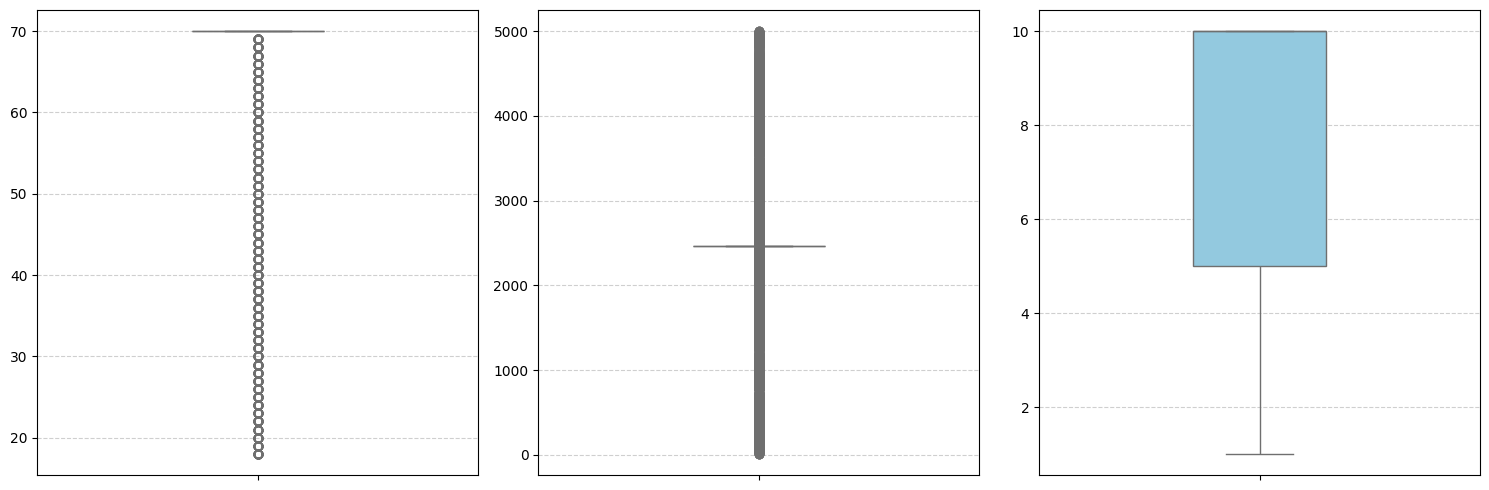

In [90]:
cols = ['Age', 'purchase_amount', 'feedback_score']
plt.figure(figsize=(15,5))

for i, col in enumerate(cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=df[col], color='skyblue', width= 0.3)
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

In [95]:
from scipy import stats
import numpy as np

In [97]:
z_score =np.abs(stats.zscore(df[['Age', 'purchase_amount']]))

In [99]:
df[(z_score >3).any(axis=1)]

,CustomerID,Name,Gender,Age,City,Signup_Date,Last_purchase_date,purchase_amount,feedback_score,email,Phone_number,Country
26,27,Kiran,M,70.0,Kolkata,28/05/2024,01/01/1970,4772.570,4.0,user26mail.com,Not Provided,UK
27,28,Neha,F,70.0,Ahmedabad,07/12/2022,01/01/1970,84.020,2.0,user27mail.com,9693394106,Australia
30,31,Sneha,M,21.0,Mumbai,28/02/2025,01/01/1970,2460.355,10.0,user30mail.com,9919454989,USA
31,32,Rahul,F,70.0,Hyderabad,07/12/2022,01/01/1970,41.610,10.0,Unknown,Not Provided,Canada
48,49,Sneha,M,22.0,Mumbai,07/12/2022,01/01/1970,2460.355,5.0,user48@mail.com,Not Provided,Australia
...,...,...,...,...,...,...,...,...,...,...,...,...
9942,9943,Amit,M,19.0,Delhi,07/12/2022,01/01/1970,1257.680,10.0,Unknown,Not Provided,Canada
9954,9955,Unknown Customer,F,18.0,Hyderabad,14/06/2021,01/01/1970,2915.490,10.0,user9954mail.com,Not Provided,India
9959,9960,Unknown Customer,F,70.0,Delhi,01/10/2024,01/01/1970,4690.790,10.0,user9959mail.com,9550268128,Canada
9964,9965,Priya,F,22.0,Hyderabad,07/12/2022,01/01/1970,2460.355,10.0,Unknown,9719064706,Canada


In [101]:
df_clean = df[~(z_score>3).any(axis=1)]

In [103]:
df_clean.shape

(9447, 12)